In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hcrseq.amplicon.plotting import temporal_plot

In [2]:
# Load and format data
R = pd.read_csv('../data/final_merged_set.repair_measurements.csv')
R[['cell_line','condition','timepoint','replicate']] = R['sample'].str.split('_',expand=True)
R['timepoint'] = R['timepoint'].str.extract(r'(\d+)h').astype(float)


In [3]:
# Filter samples to timecourse set
R = R[R['condition'].isin(['WT'])&~R['cell_line'].isin(['U2OSPatty'])]

In [4]:
# Define the order of pathway plotting
pathway_order = ['BER_8oxoG_C',
                 'BER_A_8oxoG',
                 'BER_Hx',
                 'BER_UG',
                 'DR_O6MeG',
                 'MMR',
                 'NER',
                 'NHEJ',
                 'MMEJ']
R['pathway'] = pd.Categorical(R['pathway'],pathway_order)

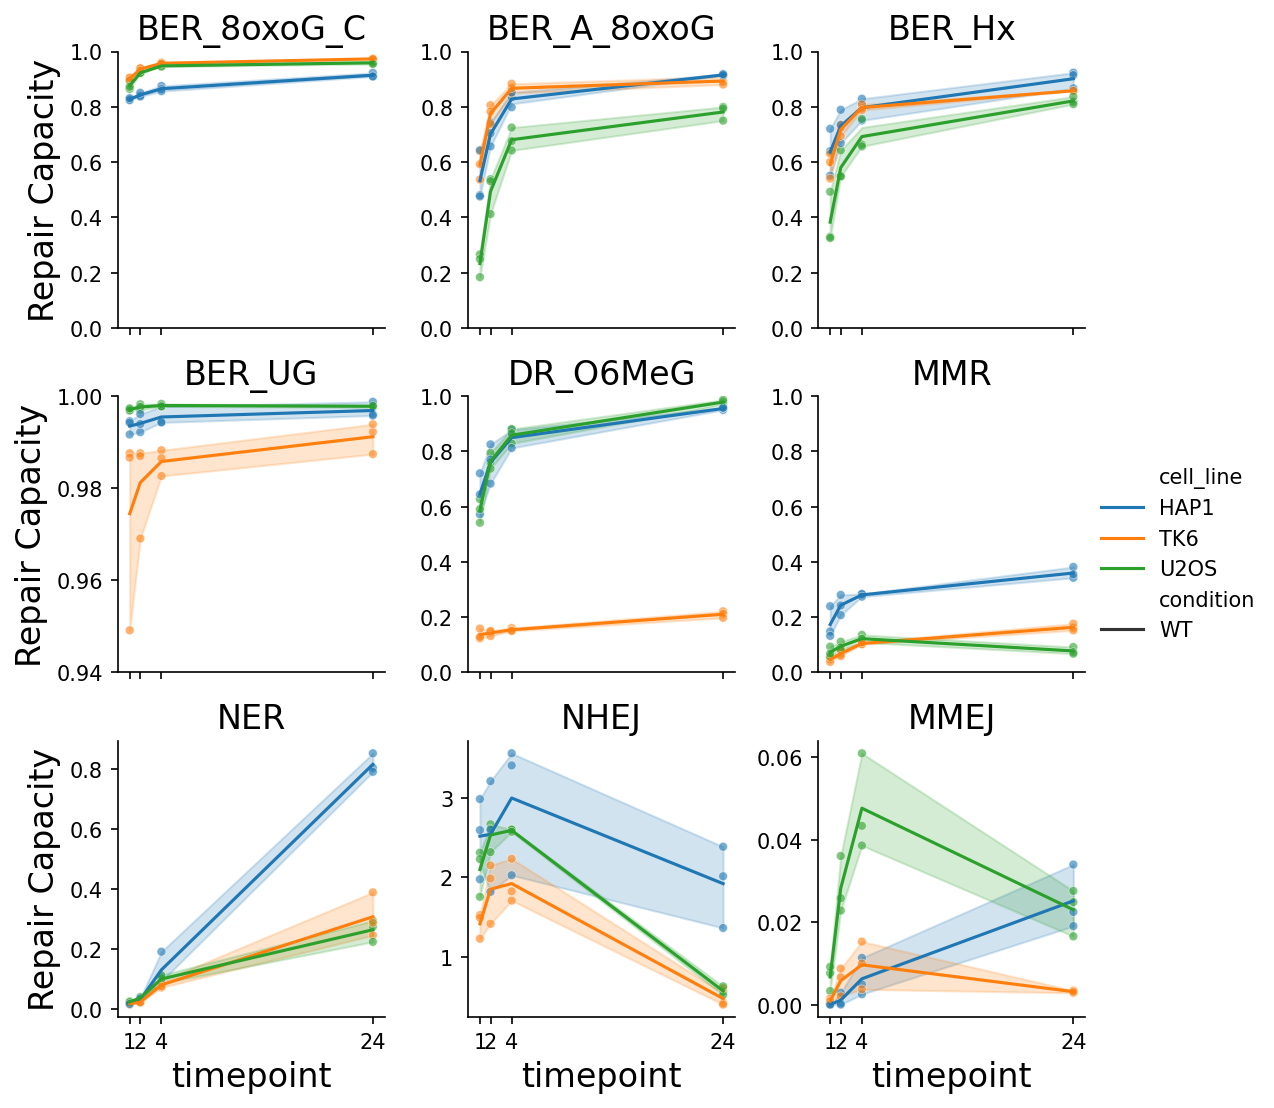

In [5]:
# Make the plot
g= temporal_plot(R,hue='cell_line',
                     units=None,
                     style='condition',
                     draw_individual_errorbars=False,
                     draw_individual_points=True)

# Customize a ylim
g.axes_dict['BER_UG'].set_ylim([.94,1])

# Customize xticks
g.set(xticks=[1,2,4,24])


plt.savefig('pdf/figure4_temporal_plot.pdf',bbox_inches="tight")